# Dự đoán giá cổ phiếu FPT - Hidden Markov Model + Log-Likelihood Similarity

**Dataset:** FPT.csv  
**Thuật toán:** Huấn luyện HMM trên dữ liệu lịch sử, sau đó dùng **độ tương đồng log-likelihood** trong không gian sliding window để dự đoán giá đóng cửa ngày mai.

## Các bước chính (theo paper)
1. **Model Training** — Huấn luyện HMM (Baum-Welch)
2. **Sliding Window Generation** — Tạo các cửa sổ trượt kích thước w
3. **Log-Likelihood Computation** — Tính ln P(Wᵢ | HMM) cho mỗi cửa sổ
4. **Similarity Calculation** — D(i,T) = (lᵢ − l_T)²
5. **Nearest Window Selection** — Chọn n=5 cửa sổ tương đồng nhất
6. **Price Prediction** — y_{T+1} = y_T + mean(Δgiá của n cửa sổ gần nhất)

| Thành phần | Ký hiệu | Ý nghĩa |
|---|---|---|
| Hidden states | Q = {0,...,N-1} | Chế độ thị trường ẩn |
| Observations | O = {0,...,M-1} | Tổ hợp return × volume rời rạc hoá |
| π[i] | Xác suất ban đầu | P(state₀ = i) |
| A[i,j] | Transition matrix | P(state_{t+1}=j \| state_t=i) |
| B[i,k] | Emission matrix | P(obs=k \| state=i) |

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
print('Ready.')

Ready.


## 1. Load & Tiền xử lý

In [49]:
df = pd.read_csv('FPT.csv', parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)

df['return'] = df['close'].pct_change()
df['vol_sma20'] = df['volume'].rolling(20).mean()
df['vol_ratio'] = df['volume'] / df['vol_sma20']

df = df.dropna(subset=['return', 'vol_ratio']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Khoang thoi gian: {df["time"].min().date()} -> {df["time"].max().date()}')
df[['time', 'close', 'return', 'vol_ratio']].head(5)

Shape: (1350, 9)
Khoang thoi gian: 2019-11-01 -> 2025-03-28


,time,close,return,vol_ratio
0,2019-11-01,21.14,0.010516,1.297117
1,2019-11-04,21.64,0.023652,3.853848
2,2019-11-05,21.60,-0.001848,0.824640
3,2019-11-06,21.50,-0.004630,1.011606
4,2019-11-07,21.50,0.000000,0.918687


## 2. Rời rạc hoá quan sát (Discretization)

HMM thuần tuý cần **observation rời rạc**. Dùng 2 feature → **6 ký hiệu quan sát**:
- **return**: Negative (< −1%) / Neutral (±1%) / Positive (> +1%) → 3 mức
- **vol_ratio**: Low (≤ 1.0) / High (> 1.0) → 2 mức

| Symbol | Return | Volume | Diễn giải |
|---|---|---|---|
| 0 | Negative | Low | Giảm nhẹ, thanh khoản thấp |
| 1 | Negative | High | Giảm mạnh, bán tháo |
| 2 | Neutral | Low | Đi ngang, ít giao dịch |
| 3 | Neutral | High | Đi ngang, tích lũy |
| 4 | Positive | Low | Tăng nhẹ, ít giao dịch |
| 5 | Positive | High | Tăng mạnh, mua vào |

In [50]:
def discretize(df):
    r = np.where(df['return'] < -0.01, 0,
         np.where(df['return'] >  0.01, 2, 1))
    v = (df['vol_ratio'] > 1.0).astype(int).values
    return r * 2 + v

df['Obs'] = discretize(df)

N_OBS    = 6
N_STATES = 4
obs_labels = ['Neg_LVol', 'Neg_HVol', 'Neut_LVol', 'Neut_HVol', 'Pos_LVol', 'Pos_HVol']

print('Phan phoi observation symbols:')
for i in range(N_OBS):
    c = (df['Obs'] == i).sum()
    print(f'  [{i}] {obs_labels[i]:12s}: {c:4d} ({c/len(df)*100:.1f}%)')

Phan phoi observation symbols:
  [0] Neg_LVol    :  104 (7.7%)
  [1] Neg_HVol    :  153 (11.3%)
  [2] Neut_LVol   :  569 (42.1%)
  [3] Neut_HVol   :  206 (15.3%)
  [4] Pos_LVol    :  119 (8.8%)
  [5] Pos_HVol    :  199 (14.7%)


## 3. Chia Train / Test theo thời gian (80/20)

In [51]:
cut = int(len(df) * 0.8)

train_df = df.iloc[:cut].copy().reset_index(drop=True)
test_df  = df.iloc[cut:].copy().reset_index(drop=True)

train_obs   = train_df['Obs'].values
test_obs    = test_df['Obs'].values
train_close = train_df['close'].values
test_close  = test_df['close'].values

print(f'Train: {len(train_df)} phien ({train_df["time"].min().date()} -> {train_df["time"].max().date()})')
print(f'Test:  {len(test_df)} phien ({test_df["time"].min().date()} -> {test_df["time"].max().date()})')

Train: 1080 phien (2019-11-01 -> 2024-02-28)
Test:  270 phien (2024-02-29 -> 2025-03-28)


## 4. Implement HMM từ đầu

### Các tham số
- `π[i]` — xác suất trạng thái ban đầu  
- `A[i,j]` — xác suất chuyển trạng thái  
- `B[i,k]` — xác suất phát sinh quan sát

In [52]:
class HMM:
    """Discrete HMM voi scaled forward-backward tranh numerical underflow."""

    def __init__(self, n_states, n_obs):
        self.N = n_states
        self.M = n_obs
        self._init_params()

    def _init_params(self):
        self.pi = np.random.dirichlet(np.ones(self.N))
        self.A  = np.random.dirichlet(np.ones(self.N), size=self.N)
        B = np.ones((self.N, self.M)) * 0.1
        for i in range(self.N):
            B[i, i % self.M] += 2.0
        self.B = B / B.sum(axis=1, keepdims=True)

    def forward_scaled(self, obs):
        T = len(obs)
        alpha  = np.zeros((T, self.N))
        scales = np.zeros(T)
        alpha[0]  = self.pi * self.B[:, obs[0]]
        scales[0] = alpha[0].sum() + 1e-300
        alpha[0] /= scales[0]
        for t in range(1, T):
            alpha[t]  = (alpha[t-1] @ self.A) * self.B[:, obs[t]]
            scales[t] = alpha[t].sum() + 1e-300
            alpha[t] /= scales[t]
        return alpha, scales

    def backward_scaled(self, obs, scales):
        T    = len(obs)
        beta = np.zeros((T, self.N))
        beta[T-1] = 1.0
        for t in range(T-2, -1, -1):
            beta[t]  = self.A @ (self.B[:, obs[t+1]] * beta[t+1])
            beta[t] /= scales[t+1]
        return beta

    def log_likelihood(self, obs):
        _, scales = self.forward_scaled(obs)
        return np.sum(np.log(scales + 1e-300))

    def fit(self, sequences, n_iter=100, tol=1e-4, verbose=True):
        prev_ll = -np.inf
        for it in range(n_iter):
            pi_num = np.zeros(self.N)
            A_num  = np.zeros((self.N, self.N))
            B_num  = np.zeros((self.N, self.M))
            total_ll = 0.0
            for obs in sequences:
                T = len(obs)
                if T < 2:
                    continue
                alpha, scales = self.forward_scaled(obs)
                beta          = self.backward_scaled(obs, scales)
                total_ll     += np.sum(np.log(scales + 1e-300))
                gamma = alpha * beta
                gamma /= gamma.sum(axis=1, keepdims=True) + 1e-300
                xi = np.zeros((T-1, self.N, self.N))
                for t in range(T-1):
                    xi[t] = (alpha[t][:, None] * self.A
                             * self.B[:, obs[t+1]][None, :] * beta[t+1][None, :])
                    xi[t] /= xi[t].sum() + 1e-300
                pi_num += gamma[0]
                A_num  += xi.sum(axis=0)
                for k in range(self.M):
                    B_num[:, k] += gamma[obs == k].sum(axis=0)
            self.pi = pi_num / (pi_num.sum() + 1e-300)
            self.A  = A_num  / (A_num.sum(axis=1, keepdims=True) + 1e-300)
            self.B  = B_num  / (B_num.sum(axis=1, keepdims=True) + 1e-300)
            if verbose and (it % 10 == 0 or it == n_iter - 1):
                print(f'  Iter {it+1:3d} | Log-likelihood = {total_ll:.4f}')
            if abs(total_ll - prev_ll) < tol:
                print(f'  Hoi tu tai iter {it+1}')
                break
            prev_ll = total_ll

    def viterbi(self, obs):
        T      = len(obs)
        log_A  = np.log(self.A  + 1e-300)
        log_B  = np.log(self.B  + 1e-300)
        log_pi = np.log(self.pi + 1e-300)
        delta = np.zeros((T, self.N))
        psi   = np.zeros((T, self.N), dtype=int)
        delta[0] = log_pi + log_B[:, obs[0]]
        for t in range(1, T):
            trans    = delta[t-1][:, None] + log_A
            psi[t]   = trans.argmax(axis=0)
            delta[t] = trans.max(axis=0) + log_B[:, obs[t]]
        states = np.zeros(T, dtype=int)
        states[T-1] = delta[T-1].argmax()
        for t in range(T-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]
        return delta[T-1].max(), states


print('HMM class defined OK.')

HMM class defined OK.


## 5. Huấn luyện (Baum-Welch) — Step 1

In [53]:
model = HMM(n_states=N_STATES, n_obs=N_OBS)
print(f'Huan luyen HMM ({N_STATES} states, {N_OBS} obs) tren {len(train_obs)} phien...')
model.fit([train_obs], n_iter=100, tol=1e-4, verbose=True)
print(f'\npi = {model.pi.round(3)}')

Huan luyen HMM (4 states, 6 obs) tren 1080 phien...
  Iter   1 | Log-likelihood = -2321.3854
  Iter  11 | Log-likelihood = -1690.2872
  Iter  21 | Log-likelihood = -1687.1577
  Iter  31 | Log-likelihood = -1685.0594
  Iter  41 | Log-likelihood = -1681.9229
  Iter  51 | Log-likelihood = -1676.4371
  Iter  61 | Log-likelihood = -1673.3299
  Iter  71 | Log-likelihood = -1672.1439
  Iter  81 | Log-likelihood = -1671.0294
  Iter  91 | Log-likelihood = -1669.4152
  Iter 100 | Log-likelihood = -1666.8957

pi = [1. 0. 0. 0.]


## 6. Phân tích tham số học được

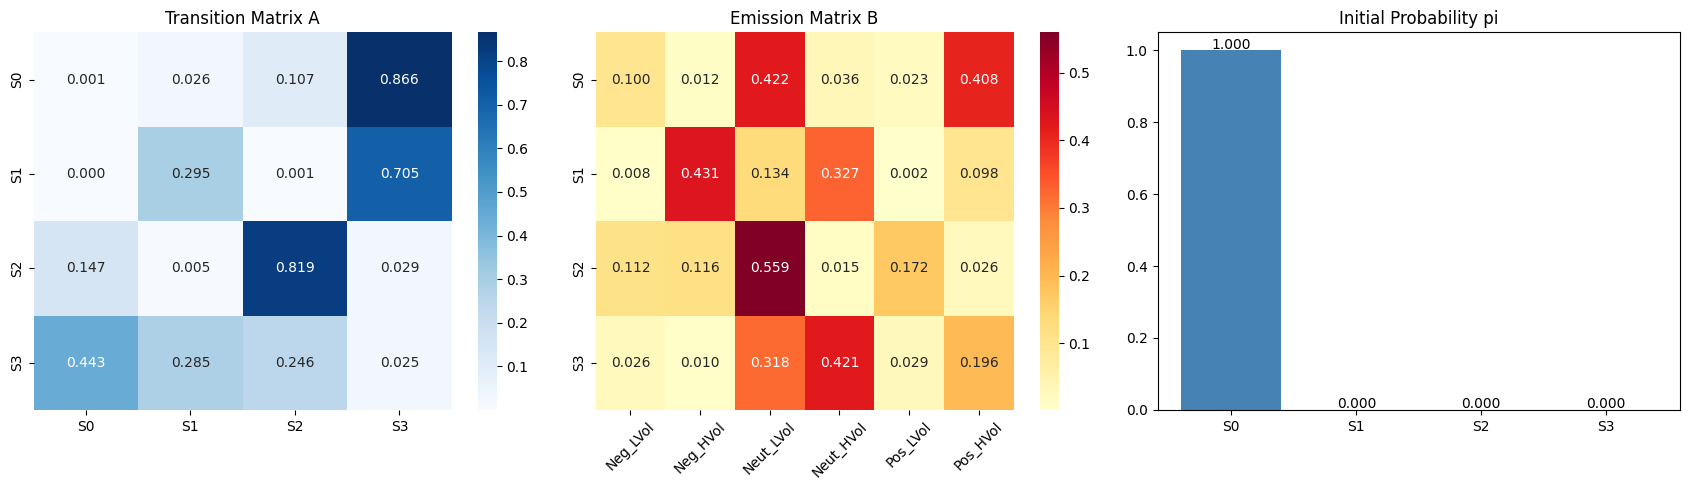

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
state_labels = [f'S{i}' for i in range(N_STATES)]

sns.heatmap(model.A, annot=True, fmt='.3f', cmap='Blues', ax=axes[0],
            xticklabels=state_labels, yticklabels=state_labels)
axes[0].set_title('Transition Matrix A')

sns.heatmap(model.B, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            xticklabels=obs_labels, yticklabels=state_labels)
axes[1].set_title('Emission Matrix B')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(range(N_STATES), model.pi, color='steelblue')
axes[2].set_title('Initial Probability pi')
axes[2].set_xticks(range(N_STATES))
axes[2].set_xticklabels(state_labels)
for i, v in enumerate(model.pi):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('hmm_fpt_params.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Sliding Window + Log-Likelihood Similarity — Steps 2–6

**Thuật toán dự đoán:**

```
Step 2: Tạo tất cả sliding windows kích thước w từ tập train
Step 3: Tính log P(Wᵢ | HMM) cho mỗi window  →  lᵢ
Step 4: Với window hiện tại l_T, tính D(i,T) = (lᵢ − l_T)²
Step 5: Chọn n=5 windows có D nhỏ nhất (tương đồng nhất)
Step 6: y_{T+1} = y_T + mean(W_{i,w+1}(close) − W_{i,w}(close))
```

**Tham số:**
- `w` = kích thước cửa sổ (số phiên trong 1 window), mặc định `w=5` (1 tuần giao dịch)
- `n` = số cửa sổ tương đồng cần chọn, mặc định `n=5` theo paper

In [55]:
WINDOW_SIZE = 5   # w: kich thuoc cua so (1 tuan giao dich)
N_SIMILAR   = 5   # n: so cua so tuong dong chon

# --- Step 2: Tao sliding windows tu tap train ---
# Moi window: w obs lien tiep + gia dong cua tai vi tri w va w+1
train_windows_obs   = []   # obs sequence cho moi window
train_windows_close = []   # (close_at_w, close_at_w1) cho moi window

for i in range(len(train_df) - WINDOW_SIZE):
    obs_win  = train_obs[i : i + WINDOW_SIZE]
    close_w  = train_close[i + WINDOW_SIZE - 1]   # gia cuoi window
    close_w1 = train_close[i + WINDOW_SIZE]        # gia ngay tiep theo
    train_windows_obs.append(obs_win)
    train_windows_close.append((close_w, close_w1))

print(f'So sliding windows tu tap train: {len(train_windows_obs)}')

# --- Step 3: Tinh log-likelihood cho tat ca windows ---
print('Tinh log-likelihood cho tat ca training windows...')
train_ll = np.array([model.log_likelihood(w) for w in train_windows_obs])
print(f'Log-likelihood: min={train_ll.min():.2f}, max={train_ll.max():.2f}, mean={train_ll.mean():.2f}')

So sliding windows tu tap train: 1075
Tinh log-likelihood cho tat ca training windows...
Log-likelihood: min=-15.16, max=-4.50, mean=-8.51


## 8. Dự đoán trên tập test

In [56]:
# Gop train + test obs/close de lay window qua ranh gioi
all_obs   = np.concatenate([train_obs,   test_obs])
all_close = np.concatenate([train_close, test_close])

# Chi so trong all_obs tuong ung voi dau tap test
test_start_idx = len(train_obs)

pred_close  = []   # gia du doan
actual_close = []  # gia thuc te
pred_dates   = []

print('Du doan tren tap test (moi ngay lay w phien truoc)...')

for i in range(len(test_df) - 1):
    idx = test_start_idx + i  # vi tri trong all_obs

    # Window hien tai: w phien ket thuc tai ngay i cua tap test
    current_obs = all_obs[idx - WINDOW_SIZE + 1 : idx + 1]
    if len(current_obs) < WINDOW_SIZE:
        continue

    # Step 3: Log-likelihood cua window hien tai
    l_T = model.log_likelihood(current_obs)

    # Step 4: Tinh khoang cach voi tat ca training windows
    distances = (train_ll - l_T) ** 2

    # Step 5: Chon n=5 windows tuong dong nhat
    top_idx = np.argsort(distances)[:N_SIMILAR]

    # Step 6: Du doan gia ngay mai
    y_T = all_close[idx]   # gia dong cua hom nay
    delta = np.mean([
        train_windows_close[j][1] - train_windows_close[j][0]
        for j in top_idx
    ])
    y_pred = y_T + delta

    pred_close.append(y_pred)
    actual_close.append(all_close[idx + 1])
    pred_dates.append(test_df['time'].iloc[i + 1])

pred_close   = np.array(pred_close)
actual_close = np.array(actual_close)
pred_dates   = pd.to_datetime(pred_dates)

print(f'So phien du doan duoc: {len(pred_close)}')
print(f'Vi du: ngay {pred_dates[0].date()} | Thuc te: {actual_close[0]:.2f} | Du doan: {pred_close[0]:.2f}')

Du doan tren tap test (moi ngay lay w phien truoc)...
So phien du doan duoc: 269
Vi du: ngay 2024-03-01 | Thuc te: 81.09 | Du doan: 78.66


## 9. Đánh giá kết quả

In [57]:
mae  = mean_absolute_error(actual_close, pred_close)
rmse = np.sqrt(mean_squared_error(actual_close, pred_close))
mape = np.mean(np.abs((actual_close - pred_close) / actual_close)) * 100
r2   = r2_score(actual_close, pred_close)

# Directional accuracy: so sanh chieu thay doi thuc te vs du doan
actual_change = np.diff(np.concatenate([[test_close[0]], actual_close]))
pred_change   = np.diff(np.concatenate([[test_close[0]], pred_close]))
dir_acc = (np.sign(actual_change) == np.sign(pred_change)).mean() * 100

print('=== Ket qua du doan gia dong cua FPT ===')
print(f'  MAE  : {mae:.4f} VND')
print(f'  RMSE : {rmse:.4f} VND')
print(f'  MAPE : {mape:.2f}%')
print(f'  R²   : {r2:.4f}')
print(f'  Directional Accuracy: {dir_acc:.1f}%')
print()
print('  Baseline (gia hom sau = gia hom nay):')
naive      = np.concatenate([[test_close[0]], actual_close[:-1]])
naive_mae  = mean_absolute_error(actual_close, naive)
naive_rmse = np.sqrt(mean_squared_error(actual_close, naive))
naive_r2   = r2_score(actual_close, naive)
print(f'    MAE = {naive_mae:.4f} | RMSE = {naive_rmse:.4f} | R² = {naive_r2:.4f}')

=== Ket qua du doan gia dong cua FPT ===
  MAE  : 1.3088 VND
  RMSE : 1.7452 VND
  MAPE : 1.21%
  R²   : 0.9836
  Directional Accuracy: 49.8%

  Baseline (gia hom sau = gia hom nay):
    MAE = 1.2836 | RMSE = 1.7074 | R² = 0.9843


## 10. Visualise kết quả

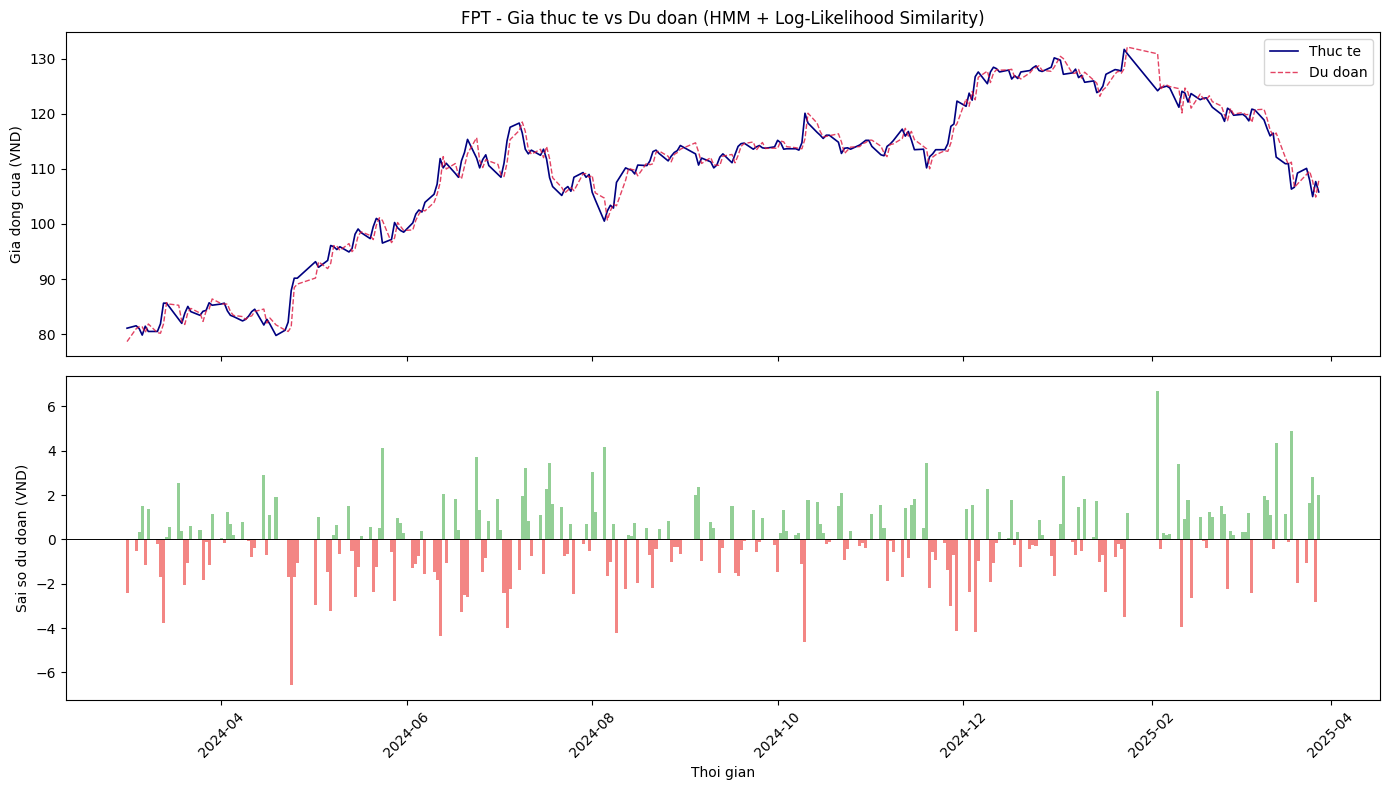

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Gia thuc te vs du doan
axes[0].plot(pred_dates, actual_close, label='Thuc te', color='navy',    linewidth=1.2)
axes[0].plot(pred_dates, pred_close,   label='Du doan', color='crimson', linewidth=1.0, alpha=0.8, linestyle='--')
axes[0].set_ylabel('Gia dong cua (VND)')
axes[0].set_title('FPT - Gia thuc te vs Du doan (HMM + Log-Likelihood Similarity)')
axes[0].legend()

# Panel 2: Sai so (error)
error = pred_close - actual_close
axes[1].bar(pred_dates, error, color=['#EF5350' if e < 0 else '#66BB6A' for e in error], alpha=0.7, width=1)
axes[1].axhline(0, color='black', linewidth=0.7)
axes[1].set_ylabel('Sai so du doan (VND)')
axes[1].set_xlabel('Thoi gian')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('hmm_fpt_prediction.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Dự đoán cho một phiên mới

In [59]:
def predict_next_close(recent_obs, current_close, model, train_ll,
                       train_windows_close, window_size=5, n_similar=5):
    """
    Du doan gia dong cua phien tiep theo.

    Args:
        recent_obs     : mang obs roi rac cua w phien gan nhat (do dai = window_size)
        current_close  : gia dong cua phien hien tai
        model          : HMM da huan luyen
        train_ll       : log-likelihood cua tat ca training windows
        train_windows_close : list cac (close_w, close_w1) cua training windows
    """
    assert len(recent_obs) == window_size, f'recent_obs phai co do dai {window_size}'

    l_T       = model.log_likelihood(np.array(recent_obs))
    distances = (train_ll - l_T) ** 2
    top_idx   = np.argsort(distances)[:n_similar]

    delta = np.mean([train_windows_close[j][1] - train_windows_close[j][0]
                     for j in top_idx])
    y_pred = current_close + delta

    return {
        'current_close' : current_close,
        'predicted_next': round(y_pred, 2),
        'delta'         : round(delta, 2),
        'similar_windows': top_idx.tolist(),
        'top5_distances': [round(float(distances[j]), 4) for j in top_idx],
    }


# Vi du: dung 5 phien cuoi tap test lam window hien tai
last_obs   = test_obs[-WINDOW_SIZE:]
last_close = test_close[-WINDOW_SIZE - 1]

result = predict_next_close(last_obs, last_close, model, train_ll,
                            train_windows_close, WINDOW_SIZE, N_SIMILAR)

print('=== Du doan phien tiep theo ===')
print(f'  Gia dong cua hien tai : {result["current_close"]:.2f}')
print(f'  Delta trung binh      : {result["delta"]:+.2f} VND')
print(f'  Gia du doan           : {result["predicted_next"]:.2f} VND')
print(f'  Chieu du doan         : {"TANG" if result["delta"] > 0 else "GIAM"}')
print(f'  5 windows tuong dong nhat (index): {result["similar_windows"]}')
print(f'  Khoang cach tuong ung : {result["top5_distances"]}')

=== Du doan phien tiep theo ===
  Gia dong cua hien tai : 109.23
  Delta trung binh      : -0.04 VND
  Gia du doan           : 109.19 VND
  Chieu du doan         : GIAM
  5 windows tuong dong nhat (index): [630, 516, 344, 243, 632]
  Khoang cach tuong ung : [0.0, 0.0, 0.0, 0.0001, 0.0003]
